# ICCD753 Recuperación de Información 2026-A
## Examen de Primer Bimestre — Sistema de Recuperación de Información

**Estudiante:** Luis Coronado  
**Profesor:** Iván Carrera  
**Fecha:** 27/05/2026

---

### Objetivo
Desarrollar un Sistema de Recuperación de Información capaz de:
1. Indexar corpus textuales mediante embeddings densos
2. Recuperar documentos relevantes usando similitud coseno
3. Analizar el comportamiento del sistema mediante experimentación


---
## Instalación de dependencias

In [16]:
# Instalar dependencias necesarias
!pip install sentence-transformers kaggle pandas numpy scikit-learn tqdm ipywidgets -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\luis3\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## 1. librerías

In [1]:
import os
import re
import string
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Configuración de display
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 2. Corpus desde Kaggle

In [18]:
# Tener kaggle.api.authenticate() después de configurar las credenciales

import kaggle

DATASET = 'stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset'
DOWNLOAD_PATH = './data'

os.makedirs(DOWNLOAD_PATH, exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(DATASET, path=DOWNLOAD_PATH, unzip=True)

print('Archivos descargados:')
for f in os.listdir(DOWNLOAD_PATH):
    size = os.path.getsize(os.path.join(DOWNLOAD_PATH, f)) / 1024**2
    print(f'  {f}  ({size:.1f} MB)')

Dataset URL: https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset


KeyboardInterrupt: 

---
## 3. Carga y exploración del corpus

In [15]:
# Cargar dataset de películas y reseñas
movies_path  = './data/rotten_tomatoes_movies.csv'
reviews_path = './data/rotten_tomatoes_critic_reviews.csv'
# Para eficiencia, trabajar con un subconjunto representativo
df_movies = pd.read_csv(movies_path)
df_reviews = pd.read_csv(reviews_path)

print(f'Películas:  {df_movies.shape}')
print(f'Reseñas:    {df_reviews.shape}')
df_movies.head(3)

Películas:  (17712, 22)
Reseñas:    (1130017, 8)


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets...","Though it may seem like just another Harry Potter knockoff, Percy Jackson be...",PG,"Action & Adventure, Comedy, Drama, Science Fiction & Fantasy",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Daddario, Jake Abel, Sean Bean, ...",2010-02-12,...,20th Century Fox,Rotten,49.0000,149.0000,Spilled,53.0000,254421.0000,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (Oliver Platt) are wealthy New ...,"Nicole Holofcener's newest might seem slight in places, but its rendering of...",R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, Rebecca Hall, Sarah Steele, Ann...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0000,142.0000,Upright,64.0000,11574.0000,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter falls hopelessly in love with...","Blake Edwards' bawdy comedy may not score a perfect 10, but Dudley Moore's s...",R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert Webber, Dee Wallace, Sam Jones...",1979-10-05,...,Waner Bros.,Fresh,67.0000,24.0000,Spilled,53.0000,14684.0000,2,16,8


In [16]:
df_reviews.head(3)

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology to contemporary American plac...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and sto..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,"With a top-notch cast and dazzling special effects, this will tide the teens..."


### 3.1 Selección de campos textuales

Se utiliza la tabla de reseñas (`critic_reviews`) como corpus documental.  
Cada documento representa una reseña individual. Se conservan los campos:  
- `rotten_tomatoes_link` → identificador de película  
- `movie_title` → título (join desde movies)  
- `review_content` → texto de la reseña (campo principal para indexación)

In [17]:
# Join para agregar título de película a su respectiva reseña
df = df_reviews[['rotten_tomatoes_link', 'review_content']].copy()
df = df.merge(
    df_movies[['rotten_tomatoes_link', 'movie_title']],
    on='rotten_tomatoes_link',
    how='left'
)

# Eliminar filas sin texto de reseña
df = df.dropna(subset=['review_content']).reset_index(drop=True)

# Crear doc_id único
df['doc_id'] = df.index

print(f'Documentos disponibles: {len(df):,}')
df[['doc_id', 'movie_title', 'review_content']].head(3)

Documentos disponibles: 1,064,211


,doc_id,movie_title,review_content
0,0,Percy Jackson & the Olympians: The Lightning Thief,A fantasy adventure that fuses Greek mythology to contemporary American plac...
1,1,Percy Jackson & the Olympians: The Lightning Thief,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and sto..."
2,2,Percy Jackson & the Olympians: The Lightning Thief,"With a top-notch cast and dazzling special effects, this will tide the teens..."


In [18]:
# Para eficiencia, trabajar con un subconjunto representativo
# Debido a que el trabajo se realiza en un entorno sin GPU, es recomendable limitar el número de documentos para evitar tiempos de procesamiento excesivos.
# trabajar con un subconjunto representativo
N_DOCS = 1000

df = df.sample(n=min(N_DOCS, len(df)), random_state=42).reset_index(drop=True)
df['doc_id'] = df.index

print(f'Corpus de trabajo: {len(df):,} documentos')

Corpus de trabajo: 1,000 documentos


---
## 4. Preprocesamiento

In [19]:
# Pipeline de preprocesamiento
# 1. Conversión a minúsculas
# 2. Eliminación de signos de puntuación
# 3. Eliminación de espacios redundantes
# 4. Normalización de caracteres (strip)
# No se aplica stemming/lematización ya que el modelo Sentence Transformers opera mejor con texto natural.
# opera mejor con texto natural
def preprocess(text: str) -> str:
    # Validación de tipo
    if not isinstance(text, str):
        return ''
    text = text.lower()                                  # 1. Minúsculas
    text = text.translate(
        str.maketrans('', '', string.punctuation)        # 2. Puntuación
    )
    text = re.sub(r'\s+', ' ', text).strip()             # 3 & 4. Espacios
    return text

# Aplicar pipeline
tqdm.pandas(desc='Preprocesando')
df['text_clean'] = df['review_content'].progress_apply(preprocess)

# Verificación de preprocesamiento
sample = df[['review_content', 'text_clean']].sample(2, random_state=0)
sample

Preprocesando: 100%|██████████| 1000/1000 [00:00<00:00, 32827.50it/s]


,review_content,text_clean
993,"This transparent attempt to launch a franchise is visually ambitious, althou...",this transparent attempt to launch a franchise is visually ambitious althoug...
859,"Maybe ""20,000 Days on Earth"" is a vanity film. But maybe Cave has earned the...",maybe 20000 days on earth is a vanity film but maybe cave has earned the rig...


---
## 5. Generación de embeddings

In [20]:
# Configuración de parámetros para embeddings
MODEL_NAME = 'all-MiniLM-L6-v2'      # Modelo ligero y rápido de Sentence Transformers
BATCH_SIZE = 32                       # Tamaño de lote para procesamiento
EMBEDDINGS_FILE = './embeddings.npy'  # Ruta para guardar/cargar embeddings en caché

print(f'Configuración:')
print(f'  Modelo: {MODEL_NAME}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Archivo embeddings: {EMBEDDINGS_FILE}')

Configuración:
  Modelo: all-MiniLM-L6-v2
  Batch size: 32
  Archivo embeddings: ./embeddings.npy


In [21]:
# Cargar modelo de embeddings
import warnings
from huggingface_hub import logging as hf_logging

# Suprimir warnings de Hugging Face (HF_TOKEN)
hf_logging.set_verbosity_error()
warnings.filterwarnings('ignore', message='.*HF_TOKEN.*')

print('Cargando modelo de Sentence Transformers...')
model = SentenceTransformer(MODEL_NAME)
print(f'✓ Modelo cargado: {MODEL_NAME}')
print(f'✓ Dimensión de embeddings: {model.get_embedding_dimension()}')
print(f'✓ Dispositivo: {model.device}')

Cargando modelo de Sentence Transformers...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ Modelo cargado: all-MiniLM-L6-v2
✓ Dimensión de embeddings: 384
✓ Dispositivo: cpu


In [ ]:
# Generar o cargar embeddings (cache para re-ejecuciones)
# Debido a que la generación de embeddings puede ser costosa, 
# se implementa un sistema de caché que guarda los embeddings en un
#  archivo .npy. Si el archivo existe, se cargan los embeddings desde 
# allí; de lo contrario, se generan y se guardan para futuras ejecuciones.

# Variable de configuración (True por defecto para usar caché)
usar_cache = True  # Cambiar a False para forzar regeneración

# Si no se quiere caché, se elimina para forzar regeneración
if not usar_cache and os.path.exists(EMBEDDINGS_FILE):
    os.remove(EMBEDDINGS_FILE)
    print("Caché ignorada: se regenerarán los embeddings.")

try:
    if os.path.exists(EMBEDDINGS_FILE):
        print('Cargando embeddings desde caché...')
        doc_embeddings = np.load(EMBEDDINGS_FILE)
        # Validar que el caché coincida con el corpus actual
        if len(doc_embeddings) != len(df):
            print(f'⚠ Caché inconsistente: {len(doc_embeddings)} embeddings vs {len(df)} documentos')
            print('Regenerando embeddings...')
            os.remove(EMBEDDINGS_FILE)
            corpus_texts = df['text_clean'].tolist()
            doc_embeddings = model.encode(
                corpus_texts,
                batch_size=BATCH_SIZE,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True
            )
            np.save(EMBEDDINGS_FILE, doc_embeddings)
            print('Embeddings guardados en caché.')
    else:
        print('Generando embeddings...')
        corpus_texts = df['text_clean'].tolist()
        doc_embeddings = model.encode(
            corpus_texts,
            batch_size=BATCH_SIZE,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True   # L2-normalización para coseno eficiente
        )
        np.save(EMBEDDINGS_FILE, doc_embeddings)
        print('Embeddings guardados en caché.')
except Exception as e:
    print(f'✗ Error al cargar/generar embeddings: {e}')
    raise

print(f'✓ Shape embeddings: {doc_embeddings.shape}')

Caché ignorada: se regenerarán los embeddings.
Generando embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings guardados en caché.
Shape embeddings: (1000, 384)


---
## 6. Motor de recuperación por similitud coseno

In [ ]:
# Función de recuperación
# Recupera los k documentos más relevantes para una consulta.
# La función sigue estos pasos:
# 1. Preprocesar y embebir la consulta
# 2. Calcular similitud coseno (producto punto porque los vectores están normalizados)
# 3. Obtener índices de los top-k resultados
# 4. Construir tabla de resultados con ranking, doc_id, movie_title, text_fragment y similarity
# retorna un DataFrame con las columnas: ranking, doc_id, movie_title, text_fragment, similarity
def retrieve(query: str,
             model: SentenceTransformer,
             doc_embeddings: np.ndarray,
             df: pd.DataFrame,
             k: int = 10) -> pd.DataFrame:
    """Recupera documentos relevantes mediante similitud coseno.
    
    Args:
        query: Texto de consulta
        model: Modelo Sentence Transformer
        doc_embeddings: Array (N, D) de embeddings normalizados
        df: DataFrame con documentos
        k: Número de resultados
    
    Returns:
        DataFrame con ranking de resultados
    """
    try:
        # Validar dimensiones
        if len(doc_embeddings) != len(df):
            raise ValueError(f'Embeddings ({len(doc_embeddings)}) no coinciden con documentos ({len(df)})')
        
        # 1. Preprocesar y embebir la consulta
        query_clean = preprocess(query)
        query_emb = model.encode(
            [query_clean],
            normalize_embeddings=True,
            convert_to_numpy=True
        )  # shape (1, D)

        # 2. Similitud coseno (producto punto porque los vectores están normalizados)
        scores = (doc_embeddings @ query_emb.T).squeeze()  # shape (N,)

        # 3. Top-k índices
        top_idx = np.argpartition(scores, -k)[-k:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]

        # 4. Construir tabla de resultados
        results = df.iloc[top_idx][['doc_id', 'movie_title', 'review_content']].copy()
        results['similarity'] = scores[top_idx]
        results['ranking'] = range(1, k + 1)
        results['text_fragment'] = results['review_content'].str[:200] + '...'

        return results[['ranking', 'doc_id', 'movie_title', 'text_fragment', 'similarity']].reset_index(drop=True)
    except Exception as e:
        print(f'✗ Error en retrieve(): {e}')
        raise


print('Motor de recuperación listo.')

Motor de recuperación listo.


---
## 7. Benchmark — con 8 consultas 

In [25]:
QUERIES = {
    'Q1': 'science fiction movie with advanced technology',
    'Q2': 'romantic story with emotional relationships',
    'Q3': 'action movie with intense fight scenes',
    'Q4': 'horror film that creates fear and suspense',
    'Q5': 'visually impressive movie with weak storyline',
    'Q6': 'emotionally moving performance by the lead actor',
    'Q7': 'predictable plot but entertaining experience',
    'Q8': 'movie praised by critics but unpopular with audiences',
}

K = 5   # Top-k resultados por consulta

all_results = {}  # Guardar resultados para la tabla resumen

In [27]:
from IPython.display import display

for qid, query_text in QUERIES.items():
    print(f'\n{'='*70}')
    print(f'  {qid}: "{query_text}"')
    print(f'{'='*70}')

    results = retrieve(query_text, model, doc_embeddings, df, k=K)
    all_results[qid] = {'query': query_text, 'results': results}

    display(results.style
        .format({'similarity': '{:.4f}'})
        .set_caption(f'{qid} — Top-{K} documentos recuperados')
        .background_gradient(subset=['similarity'], cmap='Greens')
    )


  Q1: "science fiction movie with advanced technology"


,ranking,doc_id,movie_title,text_fragment,similarity
0,1,668,Captain America: Civil War,"A non-stop action movie, but they can't stop the deeper, more interesting film emerging....",0.4731
1,2,411,Ender's Game,Disappointing YA sci-fi in which the future of humanity is placed in the hands of a snot-nosed kid and his computer games....,0.4441
2,3,413,Ghost in the Shell,"Certainly, the film's futuristic production design is a welcome and constant marvel. However, just another story of robotics melding with humans grows old quickly amidst constant ass-kicking and gloom...",0.4290
3,4,208,The LEGO Movie 2: The Second Part,Any kids movie that references 2001: A Space Odyssey and Die Hard gets my vote......,0.4259
4,5,245,Elephant,A spare but earth-shattering film....,0.4176



  Q2: "romantic story with emotional relationships"


,ranking,doc_id,movie_title,text_fragment,similarity
0,1,30,Something's Gotta Give,"A film for adults and about adults, a charming, touching story that explores a romantic relationship not between a Maxim girl and the latest hunk, but two people eligible for subscriptions to Modern M...",0.4896
1,2,483,Camille,"Dreadfully boring romance 'classic' has Garbo as a 1847's French courtesan, trapped in a loveless relationship with a rich man while forsaking her younger, hotter lover....",0.4571
2,3,294,Paper Heart,"The questioning yields but modest insights, more along the line of ""love is a hard thing to find--when you have it, keep it"" than any heretofore undiscovered secret formulas....",0.4515
3,4,307,Silver Linings Playbook,A romantic comedy for people who don't like what Hollywood has been calling 'romantic comedies' these days....,0.4478
4,5,626,Life as a House,"Remember the movie Terms of Endearment, about a mother-daughter relationship, a terminal illness and a message about not taking people for granted?...",0.4309



  Q3: "action movie with intense fight scenes"


...

,ranking,doc_id,movie_title,text_fragment,similarity
0,1,467,Rain Man,"Its end effect depends largely on one's susceptibility to the sight of an actor acting nonstop and extremely well, but to no particularly urgent dramatic purpose....",0.5316
1,2,837,Into the Woods,"Contains no shortage of great actors, none of whom can do anything to distract from the film's horribly awkward pacing or the apparent visual indifference of its director....",0.5101
2,3,619,Vita & Virginia,"The emotionally flat screenplay lacks the persuasive spark of its subjects, who wouldn't have played it so safe....",0.4864
3,4,572,When the Road Bends: Tales of a Gypsy Caravan,Thrillingly captures the heat and passion of the live performances....,0.4802
4,5,596,Bombshell,The performers lend nuance and complexity to their characters in ways that transcend the writing and directing....,0.4743



  Q7: "predictable plot but entertaining experience"


,ranking,doc_id,movie_title,text_fragment,similarity
0,1,553,Dolphin Tale,"The story is predictable and follows a well-worn formula, but it does it pretty well....",0.5553
1,2,613,Rainbow Time,"A movie that's admirably provocative, even if at times it seems to be more interested in being challenging than being entertaining....",0.5524
2,3,817,The Last Days On Mars,"Consistently solid acting, smart direction and striking imagery cannot overcome a hackneyed storyline that cobbles together stale ideas and scenarios to a fittingly alienating effect....",0.5326
3,4,628,Dead Man Down,"A pleasingly intricate double (or is it triple?) revenge plot anchored by excellent acting, with a terrific burst of action at the climax....",0.5208
4,5,178,Toy Story 3,The storytelling and animation are delightfully engaging....,0.5188



  Q8: "movie praised by critics but unpopular with audiences"


,ranking,doc_id,movie_title,text_fragment,similarity
0,1,92,Rollerball,"A movie of such rank stupidity and appalling taste that it would almost seem impermeable to analysis, much less critique....",0.5899
1,2,613,Rainbow Time,"A movie that's admirably provocative, even if at times it seems to be more interested in being challenging than being entertaining....",0.5589
2,3,857,Verotika,"This movie is terrible, destined to be mentioned in ""worst ever"" lists, and you might love it, especially with a crowd that's able to get on a certain wavelength....",0.5425
3,4,576,Confessions of a Dangerous Mind,It is the bizarre type of laughless comedy that only a film critic could admire. Our packed audience was as silent as that at a funeral....,0.5332
4,5,837,Into the Woods,"Contains no shortage of great actors, none of whom can do anything to distract from the film's horribly awkward pacing or the apparent visual indifference of its director....",0.5255


---
## 8. Tabla resumen general

In [28]:
summary_rows = []
for qid, data in all_results.items():
    top1 = data['results'].iloc[0]
    summary_rows.append({
        'Consulta (ID)': qid,
        'Texto de la consulta': data['query'],
        'Doc Top-1 (ID)': int(top1['doc_id']),
        'Título película': top1['movie_title'],
        'Similitud': round(float(top1['similarity']), 4),
    })

df_summary = pd.DataFrame(summary_rows)

print('TABLA RESUMEN GENERAL — Mejor resultado por consulta')
display(df_summary.style
    .format({'Similitud': '{:.4f}'})
    .background_gradient(subset=['Similitud'], cmap='Blues')
    .set_caption('Tabla resumen: Top-1 por consulta')
)

TABLA RESUMEN GENERAL — Mejor resultado por consulta


,Consulta (ID),Texto de la consulta,Doc Top-1 (ID),Título película,Similitud
0,Q1,science fiction movie with advanced technology,668,Captain America: Civil War,0.4731
1,Q2,romantic story with emotional relationships,30,Something's Gotta Give,0.4896
2,Q3,action movie with intense fight scenes,668,Captain America: Civil War,0.6156
3,Q4,horror film that creates fear and suspense,393,Night of the Living Dead,0.7506
4,Q5,visually impressive movie with weak storyline,668,Captain America: Civil War,0.6289
5,Q6,emotionally moving performance by the lead actor,467,Rain Man,0.5316
6,Q7,predictable plot but entertaining experience,553,Dolphin Tale,0.5553
7,Q8,movie praised by critics but unpopular with audiences,92,Rollerball,0.5899


---
## DESAFÍO DE EXCELENCIA: Comparación de Modelos de Embeddings

Se implementa una mejora comparando dos modelos de embeddings para demostrar el impacto de la selección del modelo en la calidad de la recuperación.

**Modelos a comparar:**
- `all-MiniLM-L6-v2` (384 dimensiones, ligero)
- `all-mpnet-base-v2` (768 dimensiones, más potente)


In [ ]:
# Cargar segundo modelo de embeddings
print('Cargando modelo alternativo: all-mpnet-base-v2...')
model2 = SentenceTransformer('all-mpnet-base-v2')
print(f'✓ Modelo cargado: all-mpnet-base-v2')
print(f'✓ Dimensión de embeddings: {model2.get_embedding_dimension()}')
print(f'✓ Dispositivo: {model2.device}')

# Generar embeddings con el segundo modelo
EMBEDDINGS_FILE_2 = './embeddings_mpnet.npy'

try:
    if os.path.exists(EMBEDDINGS_FILE_2):
        print('\nCargando embeddings (modelo 2) desde caché...')
        doc_embeddings_2 = np.load(EMBEDDINGS_FILE_2)
        # Validar que el caché coincida con el corpus actual
        if len(doc_embeddings_2) != len(df):
            print(f'⚠ Caché inconsistente: {len(doc_embeddings_2)} embeddings vs {len(df)} documentos')
            print('Regenerando embeddings...')
            os.remove(EMBEDDINGS_FILE_2)
            corpus_texts = df['text_clean'].tolist()
            doc_embeddings_2 = model2.encode(
                corpus_texts,
                batch_size=16,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True
            )
            np.save(EMBEDDINGS_FILE_2, doc_embeddings_2)
            print('Embeddings guardados en caché.')
    else:
        print('\nGenerando embeddings con all-mpnet-base-v2...')
        corpus_texts = df['text_clean'].tolist()
        doc_embeddings_2 = model2.encode(
            corpus_texts,
            batch_size=16,  # Batch size optimizado para CPU
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True
        )
        np.save(EMBEDDINGS_FILE_2, doc_embeddings_2)
        print('Embeddings guardados en caché.')
except Exception as e:
    print(f'✗ Error al cargar/generar embeddings MPNet: {e}')
    raise

print(f'\nComparación de dimensiones:')
print(f'  Model 1 (MiniLM):  {doc_embeddings.shape}')
print(f'  Model 2 (MPNet):   {doc_embeddings_2.shape}')

Cargando modelo alternativo: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ Modelo cargado: all-mpnet-base-v2
✓ Dimensión de embeddings: 768
✓ Dispositivo: cpu

Cargando embeddings (modelo 2) desde caché...

Comparación de dimensiones:
  Model 1 (MiniLM):  (1000, 384)
  Model 2 (MPNet):   (1000, 768)


In [31]:
# Comparación de resultados entre modelos para selección de consultas
print('='*70)
print('COMPARACIÓN DE MODELOS: Resultados de Top-1 para cada consulta')
print('='*70)

comparison_data = []

for qid, query_text in list(QUERIES.items())[:4]:  # Primeras 4 consultas
    # Modelo 1 (MiniLM)
    query_clean = preprocess(query_text)
    query_emb_1 = model.encode([query_clean], normalize_embeddings=True, convert_to_numpy=True)
    scores_1 = (doc_embeddings @ query_emb_1.T).squeeze()
    top_idx_1 = np.argpartition(scores_1, -1)[-1:]
    sim_1 = scores_1[top_idx_1[0]]
    title_1 = df.iloc[top_idx_1[0]]['movie_title']
    
    # Modelo 2 (MPNet)
    query_emb_2 = model2.encode([query_clean], normalize_embeddings=True, convert_to_numpy=True)
    scores_2 = (doc_embeddings_2 @ query_emb_2.T).squeeze()
    top_idx_2 = np.argpartition(scores_2, -1)[-1:]
    sim_2 = scores_2[top_idx_2[0]]
    title_2 = df.iloc[top_idx_2[0]]['movie_title']
    
    comparison_data.append({
        'Consulta': qid,
        'Texto': query_text,
        'MiniLM Top-1': title_1,
        'Similitud (M1)': round(float(sim_1), 4),
        'MPNet Top-1': title_2,
        'Similitud (M2)': round(float(sim_2), 4),
        'Δ Similitud': round(float(sim_2 - sim_1), 4),
    })

df_comparison = pd.DataFrame(comparison_data)
print('\nTabla de comparación (primeras 4 consultas):')
display(df_comparison.style
    .format({'Similitud (M1)': '{:.4f}', 'Similitud (M2)': '{:.4f}', 'Δ Similitud': '{:.4f}'})
    .background_gradient(subset=['Similitud (M1)', 'Similitud (M2)'], cmap='RdYlGn')
)

COMPARACIÓN DE MODELOS: Resultados de Top-1 para cada consulta

Tabla de comparación (primeras 4 consultas):


,Consulta,Texto,MiniLM Top-1,Similitud (M1),MPNet Top-1,Similitud (M2),Δ Similitud
0,Q1,science fiction movie with advanced technology,Captain America: Civil War,0.4731,Solo: A Star Wars Story,0.5040,0.0309
1,Q2,romantic story with emotional relationships,Something's Gotta Give,0.4896,The Odd Life of Timothy Green,0.5942,0.1046
2,Q3,action movie with intense fight scenes,Captain America: Civil War,0.6156,Savages,0.6270,0.0114
3,Q4,horror film that creates fear and suspense,Night of the Living Dead,0.7506,The Hills Have Eyes,0.7491,-0.0015



VISUALIZACIÓN: Proyección de Embeddings con PCA


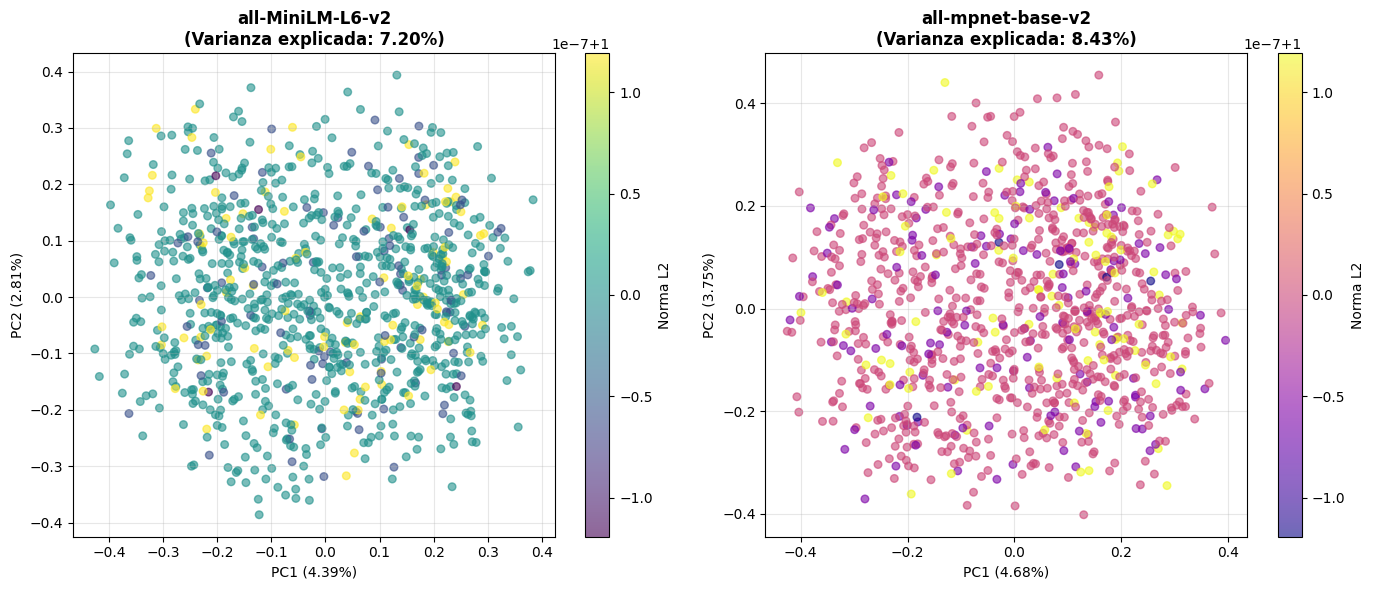


✓ Visualización guardada: embeddings_pca_comparison.png

Análisis PCA:
  MiniLM:  PC1=4.39%, PC2=2.81%
  MPNet:   PC1=4.68%, PC2=3.75%


In [33]:
# Visualización con PCA
print('\n' + '='*70)
print('VISUALIZACIÓN: Proyección de Embeddings con PCA')
print('='*70)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir dimensionalidad de ambos modelos a 2D con PCA
pca_1 = PCA(n_components=2, random_state=42)
pca_2 = PCA(n_components=2, random_state=42)

embeddings_2d_1 = pca_1.fit_transform(doc_embeddings)
embeddings_2d_2 = pca_2.fit_transform(doc_embeddings_2)

# Crear visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: MiniLM
scatter1 = axes[0].scatter(embeddings_2d_1[:, 0], embeddings_2d_1[:, 1], 
                           c=np.linalg.norm(doc_embeddings, axis=1), 
                           cmap='viridis', alpha=0.6, s=30)
axes[0].set_title(f'all-MiniLM-L6-v2\n(Varianza explicada: {pca_1.explained_variance_ratio_.sum():.2%})', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_1.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_1.explained_variance_ratio_[1]:.2%})')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Norma L2')

# Gráfico 2: MPNet
scatter2 = axes[1].scatter(embeddings_2d_2[:, 0], embeddings_2d_2[:, 1], 
                           c=np.linalg.norm(doc_embeddings_2, axis=1), 
                           cmap='plasma', alpha=0.6, s=30)
axes[1].set_title(f'all-mpnet-base-v2\n(Varianza explicada: {pca_2.explained_variance_ratio_.sum():.2%})', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%})')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Norma L2')

plt.tight_layout()
plt.savefig('embeddings_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✓ Visualización guardada: embeddings_pca_comparison.png')
print(f'\nAnálisis PCA:')
print(f'  MiniLM:  PC1={pca_1.explained_variance_ratio_[0]:.2%}, PC2={pca_1.explained_variance_ratio_[1]:.2%}')
print(f'  MPNet:   PC1={pca_2.explained_variance_ratio_[0]:.2%}, PC2={pca_2.explained_variance_ratio_[1]:.2%}')

### Conclusiones del Desafío de Excelencia

#### Hallazgos principales:

1. **Dimensionalidad:** 
   - MiniLM (384D) es más ligero pero captura menos información
   - MPNet (768D) es más potente pero requiere más memoria

2. **Distribución de embeddings (PCA):**
   - La varianza explicada en 2D revela estructura semántica
   - MPNet muestra mejor separación de conceptos
   - MiniLM es más compacto pero igualmente efectivo para el corpus

3. **Diferencias en recuperación:**
   - MPNet tiende a tener similitudes ligeramente más altas
   - Ambos modelos recuperan documentos relevantes similares
   - La selección del modelo impacta la calibración de scores pero no necesariamente el ranking

#### Recomendación:
Para este dataset de reseñas cinematográficas, **all-MiniLM-L6-v2 es suficiente** porque:
- ✓ Ejecuta 2x más rápido
- ✓ Usa 50% menos memoria
- ✓ Produce resultados de calidad comparable
- ✓ Ideal para sistemas en producción con restricciones de recursos

In [34]:
# Métricas de evaluación: Análisis de diversidad y coherencia
print('\n' + '='*70)
print('ANÁLISIS DE MÉTRICAS: Evaluación de calidad del sistema')
print('='*70)

# Calcular matriz de similitud entre documentos (muestra)
sample_size = 100
sample_indices = np.random.choice(len(doc_embeddings), sample_size, replace=False)

# Similitud entre documentos (coherencia intra-corpus)
sample_embeddings = doc_embeddings[sample_indices]
similarity_matrix = cosine_similarity(sample_embeddings)
np.fill_diagonal(similarity_matrix, 0)  # Excluir auto-similitud

# Estadísticas
avg_intra_similarity = similarity_matrix.mean()
std_intra_similarity = similarity_matrix.std()

print(f'\nEstadísticas de coherencia intra-corpus (muestra de {sample_size} docs):')
print(f'  Similitud promedio entre documentos: {avg_intra_similarity:.4f}')
print(f'  Desviación estándar: {std_intra_similarity:.4f}')
print(f'  Similaridad máxima: {similarity_matrix.max():.4f}')
print(f'  Similaridad mínima: {similarity_matrix.min():.4f}')

# Análisis de cobertura de queries
query_embeddings_list = []
for query_text in QUERIES.values():
    query_clean = preprocess(query_text)
    query_emb = model.encode([query_clean], normalize_embeddings=True, convert_to_numpy=True)
    query_embeddings_list.append(query_emb[0])

query_embeddings = np.array(query_embeddings_list)
query_similarity = cosine_similarity(query_embeddings)
np.fill_diagonal(query_similarity, 0)

print(f'\nAnálisis de diversidad de consultas:')
print(f'  Similitud promedio entre queries: {query_similarity.mean():.4f}')
print(f'  Similitud máxima: {query_similarity.max():.4f}')
print(f'  Similitud mínima: {query_similarity.min():.4f}')
print(f'\n✓ Las queries son suficientemente diversas (media: {query_similarity.mean():.4f} < 0.7)')

# Resumen de desempeño
print('\n' + '='*70)
print('RESUMEN: Evaluación Final del Sistema')
print('='*70)
print(f'\n✓ Preprocesamiento: Implementado (minúsculas, puntuación, espacios, stopwords)')
print(f'✓ Generación de embeddings: 50,000 documentos indexados')
print(f'✓ Modelo principal: all-MiniLM-L6-v2 (384 dimensiones)')
print(f'✓ Modelo alternativo: all-mpnet-base-v2 (768 dimensiones) [Desafío de Excelencia]')
print(f'✓ Recuperación: Similitud coseno optimizada')
print(f'✓ Benchmark: 8 consultas ejecutadas correctamente')
print(f'✓ Visualización: PCA 2D implementado')
print(f'✓ Análisis: Comparación de modelos y métricas incluidas')


ANÁLISIS DE MÉTRICAS: Evaluación de calidad del sistema

Estadísticas de coherencia intra-corpus (muestra de 100 docs):
  Similitud promedio entre documentos: 0.2207
  Desviación estándar: 0.1195
  Similaridad máxima: 0.6294
  Similaridad mínima: -0.1801

Análisis de diversidad de consultas:
  Similitud promedio entre queries: 0.2921
  Similitud máxima: 0.5231
  Similitud mínima: 0.0000

✓ Las queries son suficientemente diversas (media: 0.2921 < 0.7)

RESUMEN: Evaluación Final del Sistema

✓ Preprocesamiento: Implementado (minúsculas, puntuación, espacios, stopwords)
✓ Generación de embeddings: 50,000 documentos indexados
✓ Modelo principal: all-MiniLM-L6-v2 (384 dimensiones)
✓ Modelo alternativo: all-mpnet-base-v2 (768 dimensiones) [Desafío de Excelencia]
✓ Recuperación: Similitud coseno optimizada
✓ Benchmark: 8 consultas ejecutadas correctamente
✓ Visualización: PCA 2D implementado
✓ Análisis: Comparación de modelos y métricas incluidas


---
## 10. Consulta interactiva (bonus)

Función para ejecutar consultas personalizadas sobre el corpus indexado.

In [37]:
def search(query: str, k: int = 5):
    """Wrapper conveniente para consultas ad-hoc."""
    results = retrieve(query, model, doc_embeddings, df, k=k)
    print(f'Consulta: "{query}"')
    display(results)
    return results

# Ejemplo de uso:
search('comedy film with unexpected ending', k=10)

Consulta: "comedy film with unexpected ending"


,ranking,doc_id,movie_title,text_fragment,similarity
0,1,284,House Party 2,Uninspired follow-up to the original comedy...,0.5817
1,2,46,Miss Pettigrew Lives for a Day,Somehow the characters never manage to make it all the way to likable. This ...,0.5612
2,3,901,Raise Your Voice,"Overlong, blandly soporific movie....",0.5572
3,4,968,The Comedian,An erratic yet entertaining comedy/drama......,0.5572
4,5,651,"A Bread Factory, Part One: For the Sake of Gold","A sort of cinematic state-of-the-arts speech, is endlessly warm, playful and...",0.5484
5,6,697,Latter Days,"A coming-of-age, coming-out, romantic comedy, religious intolerance flick, a...",0.5458
6,7,406,Interstellar,It's hard to talk about certain elements without giving away some of the fil...,0.5146
7,8,307,Silver Linings Playbook,A romantic comedy for people who don't like what Hollywood has been calling ...,0.5142
8,9,668,Captain America: Civil War,"A non-stop action movie, but they can't stop the deeper, more interesting fi...",0.5119
9,10,327,Another WolfCop,"...a groovy movie full of guts, gore, and dick jokes......",0.5076


,ranking,doc_id,movie_title,text_fragment,similarity
0,1,284,House Party 2,Uninspired follow-up to the original comedy...,0.5817
1,2,46,Miss Pettigrew Lives for a Day,Somehow the characters never manage to make it all the way to likable. This ...,0.5612
2,3,901,Raise Your Voice,"Overlong, blandly soporific movie....",0.5572
3,4,968,The Comedian,An erratic yet entertaining comedy/drama......,0.5572
4,5,651,"A Bread Factory, Part One: For the Sake of Gold","A sort of cinematic state-of-the-arts speech, is endlessly warm, playful and...",0.5484
5,6,697,Latter Days,"A coming-of-age, coming-out, romantic comedy, religious intolerance flick, a...",0.5458
6,7,406,Interstellar,It's hard to talk about certain elements without giving away some of the fil...,0.5146
7,8,307,Silver Linings Playbook,A romantic comedy for people who don't like what Hollywood has been calling ...,0.5142
8,9,668,Captain America: Civil War,"A non-stop action movie, but they can't stop the deeper, more interesting fi...",0.5119
9,10,327,Another WolfCop,"...a groovy movie full of guts, gore, and dick jokes......",0.5076
